<h1><center>Part 3 : Developing a Multimodal Multi-Agent System for Image Understanding and Generation</center></h1>

Extend a multimodal AI system by implementing specialized agents that collaborate to analyze images, refine prompts, generate image variations, and evaluate results. The goal is to demonstrate how multiple agents interact in a coordinated multimodal workflow involving image understanding, prompt refinement, generation, and evaluation. 

In [30]:
import os
import json
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Dict, Any, Optional

import numpy as np
import pandas as pd
from PIL import Image, ImageStat
import matplotlib.pyplot as plt

import torch

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# Define project folders
INPUT_DIR = Path("input_images")
OUTPUT_DIR = Path("generated_outputs")
LOG_DIR = Path("agent_logs")

# Create folders
for folder in [INPUT_DIR, OUTPUT_DIR, LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folder structure ready:")
print(INPUT_DIR)
print(OUTPUT_DIR)
print(LOG_DIR)

Using device: cpu
Folder structure ready:
input_images
generated_outputs
agent_logs


In [31]:
from pathlib import Path

# Define supported image file extensions
valid_exts = [".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"]

# Automatically collect all valid image files from INPUT_DIR
input_image_paths = [
    p for p in INPUT_DIR.iterdir()
    if p.suffix.lower() in valid_exts
]

# Sort the list to ensure consistent order (optional)
input_image_paths = sorted(input_image_paths)

print("Registered input images:")
for p in input_image_paths:
    print(p)

# Check if any images were found
if len(input_image_paths) == 0:
    print("\nNo images found in input_images/")
else:
    print(f"\nTotal {len(input_image_paths)} images loaded.")

Registered input images:
input_images/input_1.JPG
input_images/input_2.JPG
input_images/input_3.JPG
input_images/input_4.JPG
input_images/input_5.JPEG
input_images/input_6.JPG
input_images/input_7.JPG
input_images/input_8.JPG

Total 8 images loaded.


In [32]:
from PIL import Image, ImageStat, ImageOps

def load_image(image_path: str) -> Image.Image:
    """
    Load an image, correct EXIF orientation, and convert it to RGB.
    This preserves the intended portrait or landscape orientation.
    """
    img = Image.open(image_path)
    img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")
    return img

def save_json(data: Dict[str, Any], output_path: str) -> None:
    """Save a dictionary as a JSON file."""
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)


def display_side_by_side(input_img: Image.Image, output_img: Image.Image, title1="Input", title2="Generated") -> None:
    """Display two images side by side."""
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(input_img)
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(output_img)
    plt.title(title2)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def get_basic_image_quality_signal(img: Image.Image) -> Dict[str, Any]:
    """Compute simple quality-related signals for logging and failure handling."""
    width, height = img.size
    gray = img.convert("L")
    brightness = ImageStat.Stat(gray).mean[0]

    warnings_list = []

    if width < 256 or height < 256:
        warnings_list.append("Low image resolution may reduce generation quality.")

    if brightness < 40:
        warnings_list.append("Dark image detected. Enhancement may be helpful.")

    return {
        "width": width,
        "height": height,
        "brightness": round(brightness, 2),
        "warnings": warnings_list
    }


def ensure_prompt_is_clear(user_request: str) -> str:
    """Replace overly short or ambiguous requests with a safer fallback."""
    if user_request is None or len(user_request.strip()) < 8:
        return "Enhance the image while preserving the main subject and improving visual clarity."
    return user_request.strip()

# 3.1 Vision Understanding Agent 
- <b>Task</b>: Analyze an input image and extract key visual information. 
- <b>Requirements</b>: Use a vision-language model or multimodal LLM to generate: 
    - a short image caption 
    - a list of key objects or entities 
    - a brief scene description 
    
The agent must also answer at least two visual questions about the image. 

In [33]:
# Vision Understanding Agent
from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    BlipForQuestionAnswering
)

@dataclass
class VisionOutput:
    image_path: str
    short_caption: str
    key_objects: List[str]
    scene_description: str
    visual_questions: List[str]
    visual_answers: List[str]
    image_quality_signal: Dict[str, Any]


class VisionUnderstandingAgent:
    """
    This agent analyzes an input image and generates:
    1. A short image caption
    2. A list of key objects or entities
    3. A brief scene description
    4. Answers to at least two visual questions
    """

    def __init__(self):
        # Load captioning processor and model
        self.caption_processor = BlipProcessor.from_pretrained(
            "Salesforce/blip-image-captioning-base"
        )
        self.caption_model = BlipForConditionalGeneration.from_pretrained(
            "Salesforce/blip-image-captioning-base"
        ).to(DEVICE)
        self.caption_model.eval()

        # Load VQA processor and model
        self.vqa_processor = BlipProcessor.from_pretrained(
            "Salesforce/blip-vqa-base"
        )
        self.vqa_model = BlipForQuestionAnswering.from_pretrained(
            "Salesforce/blip-vqa-base"
        ).to(DEVICE)
        self.vqa_model.eval()

    def generate_caption(self, image: Image.Image) -> str:
        """
        Generate a short caption for the input image.
        """
        inputs = self.caption_processor(images=image, return_tensors="pt")
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        with torch.no_grad():
            output = self.caption_model.generate(**inputs, max_new_tokens=30)

        caption = self.caption_processor.decode(output[0], skip_special_tokens=True)
        return caption

    def answer_visual_question(self, image: Image.Image, question: str) -> str:
        """
        Answer a visual question about the image.
        """
        inputs = self.vqa_processor(images=image, text=question, return_tensors="pt")
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        with torch.no_grad():
            output = self.vqa_model.generate(**inputs, max_new_tokens=20)

        answer = self.vqa_processor.decode(output[0], skip_special_tokens=True)
        return answer

    def extract_key_objects_from_caption(self, caption: str) -> List[str]:
        """
        Convert the caption into a rough list of key objects.
        """
        stop_words = {
            "a", "an", "the", "with", "in", "on", "at", "of", "and", "is", "are",
            "to", "for", "near", "next", "standing", "sitting"
        }

        tokens = caption.lower().replace(",", "").replace(".", "").split()
        filtered = [t for t in tokens if t not in stop_words and len(t) > 2]

        unique_tokens = []
        for token in filtered:
            if token not in unique_tokens:
                unique_tokens.append(token)

        return unique_tokens[:8]

    def build_scene_description(self, caption: str, answers: List[str]) -> str:
        """
        Combine the caption and VQA answers into a concise scene description.
        """
        return (
            f"The image appears to show {caption}. "
            f"Additional visual evidence suggests: {', '.join(answers)}."
        )

    def run(self, image_path: str) -> VisionOutput:
        """
        Run the full vision understanding pipeline on one image.
        """
        image = load_image(image_path)

        short_caption = self.generate_caption(image)

        questions = [
            "What is the main subject in this image?",
            "What kind of scene is this?",
            "What notable objects are visible?"
        ]

        answers = []
        for q in questions:
            try:
                answer = self.answer_visual_question(image, q)
                answers.append(answer)
            except Exception as e:
                answers.append(f"Unknown ({str(e)})")

        key_objects = self.extract_key_objects_from_caption(short_caption)
        scene_description = self.build_scene_description(short_caption, answers)
        quality_signal = get_basic_image_quality_signal(image)

        return VisionOutput(
            image_path=image_path,
            short_caption=short_caption,
            key_objects=key_objects,
            scene_description=scene_description,
            visual_questions=questions,
            visual_answers=answers,
            image_quality_signal=quality_signal
        )


# Run Agent
vision_agent = VisionUnderstandingAgent()
vision_results = {}

for image_path in input_image_paths:
    if image_path.exists():
        result = vision_agent.run(str(image_path))
        vision_results[image_path.name] = asdict(result)

print("Task 3.1 completed.")
print("Processed images:", list(vision_results.keys()))

# Inspect outputs
for image_name, result in vision_results.items():
    print("\n" + "=" * 80)
    print("Image:", image_name)
    print("Short caption:", result["short_caption"])
    print("Key objects:", result["key_objects"])
    print("Scene description:", result["scene_description"])
    print("Visual questions:", result["visual_questions"])
    print("Visual answers:", result["visual_answers"])
    print("Image quality signal:", result["image_quality_signal"])

Loading weights: 100%|██████████| 473/473 [00:00<00:00, 41439.29it/s]
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 788/788 [00:00<00:00, 20624.72it/s]
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Task 3.1 completed.
Processed images: ['input_1.JPG', 'input_2.JPG', 'input_3.JPG', 'input_4.JPG', 'input_5.JPEG', 'input_6.JPG', 'input_7.JPG', 'input_8.JPG']

Image: input_1.JPG
Short caption: a cloudy sky
Key objects: ['cloudy', 'sky']
Scene description: The image appears to show a cloudy sky. Additional visual evidence suggests: street, beach, palm trees.
Visual questions: ['What is the main subject in this image?', 'What kind of scene is this?', 'What notable objects are visible?']
Visual answers: ['street', 'beach', 'palm trees']
Image quality signal: {'width': 4284, 'height': 5712, 'brightness': 178.02, 'warnings': []}

Image: input_2.JPG
Short caption: a large green sign
Key objects: ['large', 'green', 'sign']
Scene description: The image appears to show a large green sign. Additional visual evidence suggests: building, outdoor, buildings.
Visual questions: ['What is the main subject in this image?', 'What kind of scene is this?', 'What notable objects are visible?']
Visual ans

# 3.2 Prompt Engineering Agent 
- <b>Task</b>: Refine the user’s instruction into a clearer prompt for generation. 
- <b>Requirements</b>: Using the user request and the output of the Vision Understanding Agent: 
    - rewrite the prompt clearly 
    - enrich it with useful visual details 
    - preserve the intended transformation (e.g., style change, scene edit, enhancement) 

In [34]:
# output schema
@dataclass
class PromptOutput:
    original_request: str
    refined_prompt: str
    transformation_type: str
    preserved_elements: List[str]
    
# Prompt Engineering Agent implementation
class PromptEngineeringAgent:
    """
    This agent refines the user request using the visual understanding output.
    It rewrites the prompt clearly, adds useful visual detail, and preserves
    the intended transformation.
    """

    def infer_transformation_type(self, request: str) -> str:
        """Infer a simple generation mode from the user request."""
        request_lower = request.lower()

        stylization_keywords = [ "watercolor", "painting", "cartoon", "sketch", "anime", "studio ghibli" ]

        enhancement_keywords = [ "enhance", "improve", "brighten", "sharpen" ]

        variation_keywords = [ "variation", "alternative" ]

        if any(k in request_lower for k in stylization_keywords):
            return "stylization"
        elif any(k in request_lower for k in enhancement_keywords):
            return "enhancement"
        elif any(k in request_lower for k in variation_keywords):
            return "variation"
        else:
            return "general_edit"

    def run(self, user_request: str, vision_output: VisionOutput) -> PromptOutput:
        """Generate a refined prompt."""
        safe_request = ensure_prompt_is_clear(user_request)
        transformation_type = self.infer_transformation_type(safe_request)

        preserved_elements = vision_output.key_objects[:5]

        refined_prompt = (
            f"{safe_request}. "
            f"Preserve the main visual content, especially {', '.join(preserved_elements)}. "
            f"The input image can be described as: {vision_output.short_caption}. "
            f"Scene context: {vision_output.scene_description}. "
            f"Maintain coherent composition and recognizable structure."
        )

        return PromptOutput(
            original_request=safe_request,
            refined_prompt=refined_prompt,
            transformation_type=transformation_type,
            preserved_elements=preserved_elements
        )
        
# define user request
user_requests = {
    "input_1": "Transform into anime style.",
    "input_2": "Improve image clarity, lighting, and overall sharpness.",
    "input_3": "Convert the image into a sketch style",
    "input_4": "Make the waterfall more vivid and visually striking.",
    "input_5": "Improve the brightness and contrast of this picture.",
    "input_6": "Transform this photo into studio ghibli style.",
    "input_7": "Enhance the image by improving sharpness, contrast, and overall visual quality.",
    "input_8": "Create a cinematic stylized version of this photo."
}

# Run the Prompt Engineering Agent
prompt_agent = PromptEngineeringAgent()
prompt_results = {}

for image_path in input_image_paths:
    image_name = image_path.name
    image_stem = image_path.stem

    if image_name in vision_results:
        vision_output = VisionOutput(**vision_results[image_name])

        user_request = user_requests.get(
            image_stem,
            "Enhance the image while preserving the main subject and overall scene structure."
        )

        result = prompt_agent.run(user_request, vision_output)
        prompt_results[image_name] = asdict(result)

print("Task 3.2 completed.")


# Inspect outputs
for image_name, result in prompt_results.items():
    print("\n" + "=" * 80)
    print("Image:", image_name)
    print("Original request:", result["original_request"])
    print("Transformation type:", result["transformation_type"])
    print("Preserved elements:", result["preserved_elements"])
    print("Refined prompt:", result["refined_prompt"])

Task 3.2 completed.

Image: input_1.JPG
Original request: Transform into anime style.
Transformation type: stylization
Preserved elements: ['cloudy', 'sky']
Refined prompt: Transform into anime style.. Preserve the main visual content, especially cloudy, sky. The input image can be described as: a cloudy sky. Scene context: The image appears to show a cloudy sky. Additional visual evidence suggests: street, beach, palm trees.. Maintain coherent composition and recognizable structure.

Image: input_2.JPG
Original request: Improve image clarity, lighting, and overall sharpness.
Transformation type: enhancement
Preserved elements: ['large', 'green', 'sign']
Refined prompt: Improve image clarity, lighting, and overall sharpness.. Preserve the main visual content, especially large, green, sign. The input image can be described as: a large green sign. Scene context: The image appears to show a large green sign. Additional visual evidence suggests: building, outdoor, buildings.. Maintain cohe

# 3.3 Image Generation Agent
- <b>Task</b>: Generate a new image based on the refined prompt. 
- <b>Requirements</b>: Use a text-to-image or image-to-image generation model to: 
    - generate at least one output image
    - support one simple generation mode such as stylization, variation, or enhancement 
    - record basic configuration details such as prompt, model used, and inference steps 

In [35]:
import gc
from diffusers import StableDiffusionImg2ImgPipeline

# output schema
@dataclass
class GenerationOutput:
    model_name: str
    prompt: str
    negative_prompt: str
    num_inference_steps: int
    strength: float
    guidance_scale: float
    output_image_path: str
    status: str
    error_message: Optional[str] = None
    
    
# Image Generation Agent implementation
class ImageGenerationAgent:
    """
    This agent generates an output image from an input image and a refined prompt.
    The implementation is optimized to reduce memory usage.
    """

    def __init__(self, model_name: str = "runwayml/stable-diffusion-v1-5"):
        self.model_name = model_name
        self.pipe = None

    def load_pipeline(self):
        """
        Load the diffusion pipeline only when needed.
        This helps reduce idle memory usage.
        """
        if self.pipe is not None:
            return

        # Select lower precision on CUDA, otherwise use float32
        dtype = torch.float16 if DEVICE == "cuda" else torch.float32

        self.pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
            self.model_name,
            torch_dtype=dtype,
            safety_checker=None,
            requires_safety_checker=False
        )

        if DEVICE == "cuda":
            self.pipe = self.pipe.to("cuda")
            self.pipe.enable_attention_slicing()
            self.pipe.enable_vae_slicing()
            self.pipe.enable_vae_tiling()

            # If accelerate is available, this may help further.
            # Uncomment if needed and if accelerate is installed.
            # self.pipe.enable_model_cpu_offload()

        else:
            self.pipe = self.pipe.to(DEVICE)

    def unload_pipeline(self):
        """
        Explicitly release pipeline memory after generation.
        """
        if self.pipe is not None:
            del self.pipe
            self.pipe = None

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

    def preprocess_for_generation(self, image: Image.Image) -> Image.Image:
        """
        Resize image to a smaller generation friendly resolution.
        Lower resolution greatly reduces memory usage.
        """
        image = image.convert("RGB")

        width, height = image.size

        # Keep resolution moderate to avoid OOM
        target_max_side = 512

        scale = min(target_max_side / max(width, height), 1.0)
        new_width = int(width * scale)
        new_height = int(height * scale)

        # Force dimensions to multiples of 64
        new_width = max(256, (new_width // 64) * 64)
        new_height = max(256, (new_height // 64) * 64)

        return image.resize((new_width, new_height))

    def run(
        self,
        image_path: str,
        prompt_output: PromptOutput,
        output_image_path: str,
        negative_prompt: str = "blurry, distorted, low quality, artifacts, duplicate",
        num_inference_steps: int = 15,
        strength: float = 0.55,
        guidance_scale: float = 6.5
    ) -> GenerationOutput:
        """
        Generate one output image with memory cleanup before and after.
        """
        try:
            # Free memory before loading pipeline
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            self.load_pipeline()

            init_image = load_image(image_path)
            init_image = self.preprocess_for_generation(init_image)

            result = self.pipe(
                prompt=prompt_output.refined_prompt,
                negative_prompt=negative_prompt,
                image=init_image,
                num_inference_steps=num_inference_steps,
                strength=strength,
                guidance_scale=guidance_scale
            )

            output_image = result.images[0]
            output_image.save(output_image_path)

            return GenerationOutput(
                model_name=self.model_name,
                prompt=prompt_output.refined_prompt,
                negative_prompt=negative_prompt,
                num_inference_steps=num_inference_steps,
                strength=strength,
                guidance_scale=guidance_scale,
                output_image_path=output_image_path,
                status="success"
            )

        except Exception as e:
            return GenerationOutput(
                model_name=self.model_name,
                prompt=prompt_output.refined_prompt,
                negative_prompt=negative_prompt,
                num_inference_steps=num_inference_steps,
                strength=strength,
                guidance_scale=guidance_scale,
                output_image_path=output_image_path,
                status="failed",
                error_message=str(e)
            )

        finally:
            # Always unload to avoid cumulative memory growth
            self.unload_pipeline()
            
# Run Agent
generation_agent = ImageGenerationAgent()
generation_results = {}

for image_path in input_image_paths:
    image_name = image_path.name

    if image_name not in prompt_results:
        print(f"Skipping {image_name} because prompt output is missing.")
        continue

    prompt_output = PromptOutput(**prompt_results[image_name])
    output_image_path = OUTPUT_DIR / f"{image_path.stem}_generated.png"

    print(f"Generating image for {image_name} ...")

    result = generation_agent.run(
        image_path=str(image_path),
        prompt_output=prompt_output,
        output_image_path=str(output_image_path),
        num_inference_steps=20,
        strength=0.35,
        guidance_scale=7.5
    )

    generation_results[image_name] = asdict(result)
    print(f"Finished {image_name}: {result.status}")

print("Task 3.3 completed.")

# Inspect outputs
for image_name, result in generation_results.items():
    print("\n" + "=" * 80)
    print("Image:", image_name)
    print("Status:", result["status"])
    print("Model used:", result["model_name"])
    print("Inference steps:", result["num_inference_steps"])
    print("Strength:", result["strength"])
    print("Guidance scale:", result["guidance_scale"])
    print("Output image path:", result["output_image_path"])
    print("Error message:", result["error_message"])

Generating image for input_1.JPG ...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 15180.48it/s]
CLIPTextModel LOAD REPORT from: /home/sandy/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 7/7 [00:15<00:00,  2.18s/it]


Finished input_1.JPG: success
Generating image for input_2.JPG ...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 17827.59it/s]
CLIPTextModel LOAD REPORT from: /home/sandy/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 7/7 [00:16<00:00,  2.38s/it]


Finished input_2.JPG: success
Generating image for input_3.JPG ...


...

Finished input_6.JPG: success
Generating image for input_7.JPG ...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 22524.69it/s]
CLIPTextModel LOAD REPORT from: /home/sandy/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 50.18it/s]
Token indices sequence length is longer than the specified maximum sequence length for this model (86 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['bedroom , clothes .. maintain coherent composition and recognizable structure .']
100%|██████████| 7/7 [00:16<00:

Finished input_7.JPG: success
Generating image for input_8.JPG ...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 16662.28it/s]
CLIPTextModel LOAD REPORT from: /home/sandy/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 43.73it/s]
Token indices sequence length is longer than the specified maximum sequence length for this model (79 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['and recognizable structure .']
100%|██████████| 7/7 [00:16<00:00,  2.42s/it]


Finished input_8.JPG: success
Task 3.3 completed.

Image: input_1.JPG
Status: success
Model used: runwayml/stable-diffusion-v1-5
Inference steps: 20
Strength: 0.35
Guidance scale: 7.5
Output image path: generated_outputs/input_1_generated.png
Error message: None

Image: input_2.JPG
Status: success
Model used: runwayml/stable-diffusion-v1-5
Inference steps: 20
Strength: 0.35
Guidance scale: 7.5
Output image path: generated_outputs/input_2_generated.png
Error message: None

Image: input_3.JPG
Status: success
Model used: runwayml/stable-diffusion-v1-5
Inference steps: 20
Strength: 0.35
Guidance scale: 7.5
Output image path: generated_outputs/input_3_generated.png
Error message: None

Image: input_4.JPG
Status: success
Model used: runwayml/stable-diffusion-v1-5
Inference steps: 20
Strength: 0.35
Guidance scale: 7.5
Output image path: generated_outputs/input_4_generated.png
Error message: None

Image: input_5.JPEG
Status: success
Model used: runwayml/stable-diffusion-v1-5
Inference steps: 2

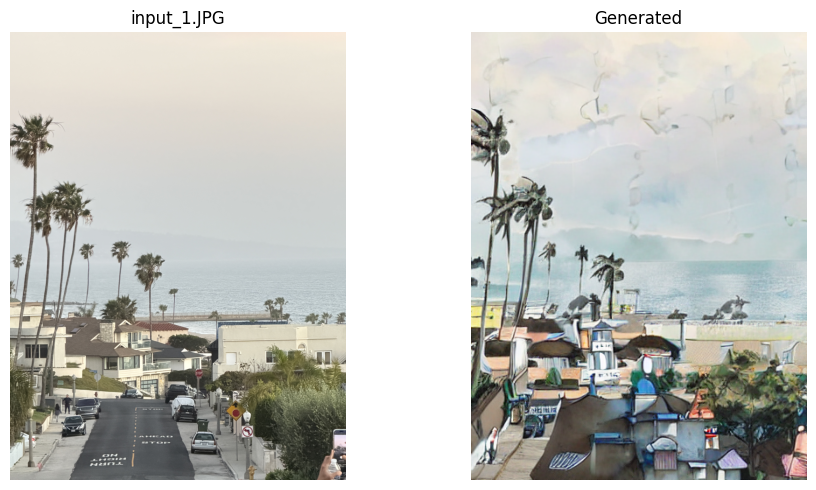

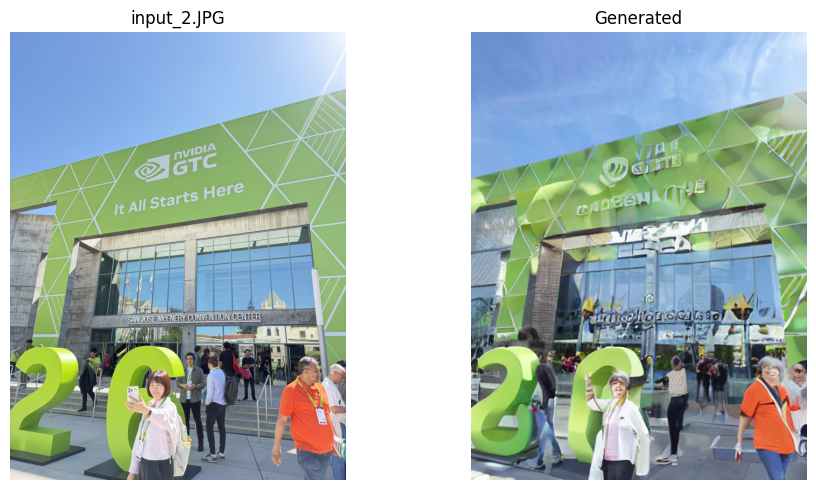

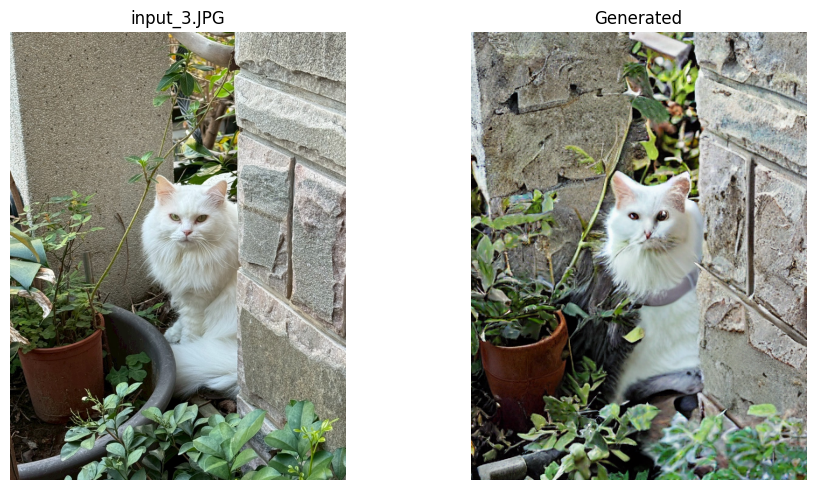

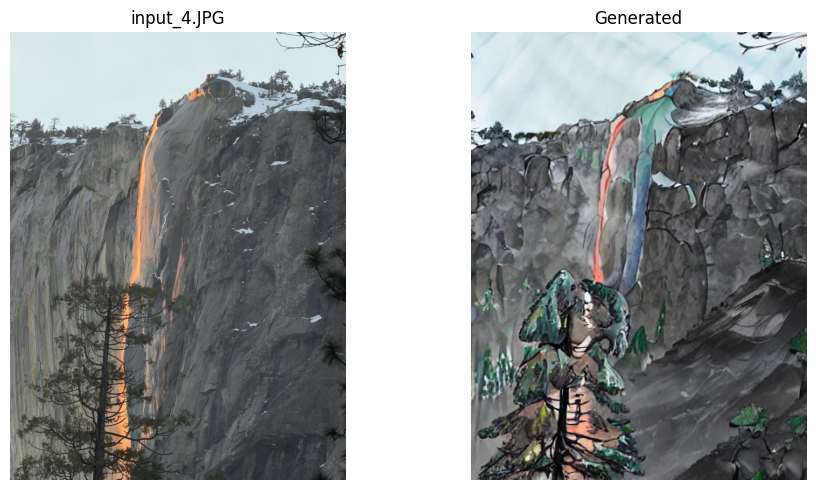

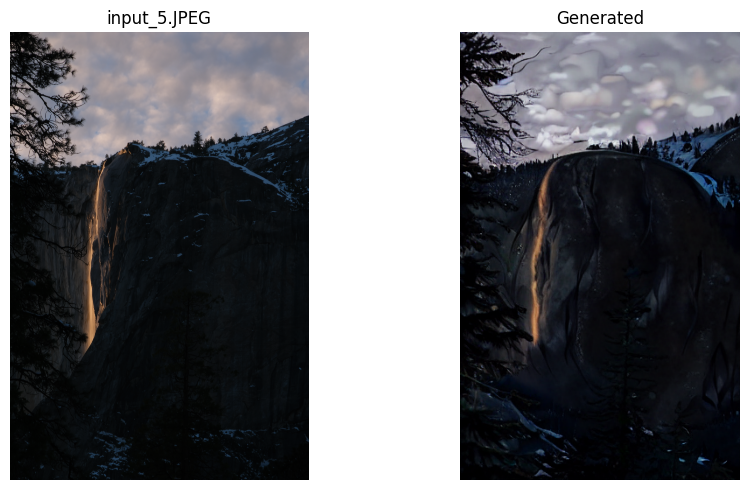

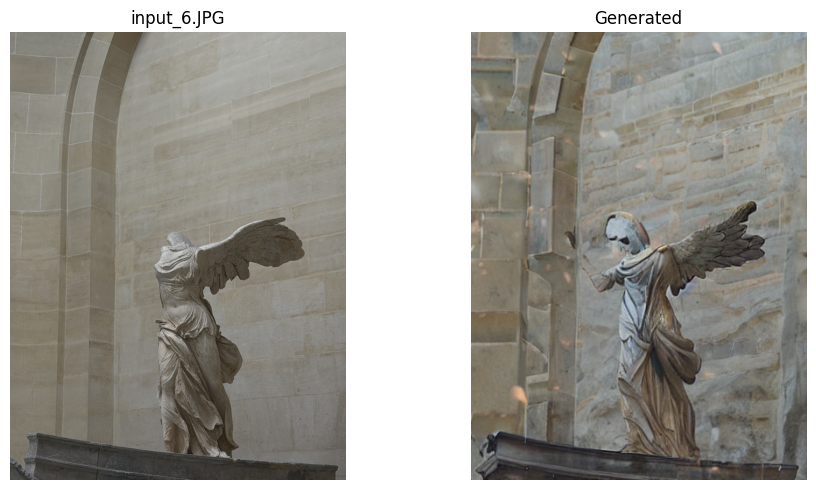

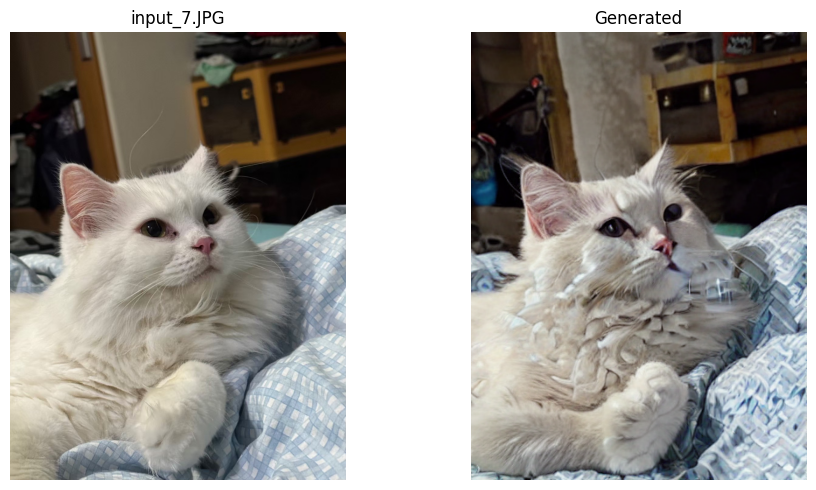

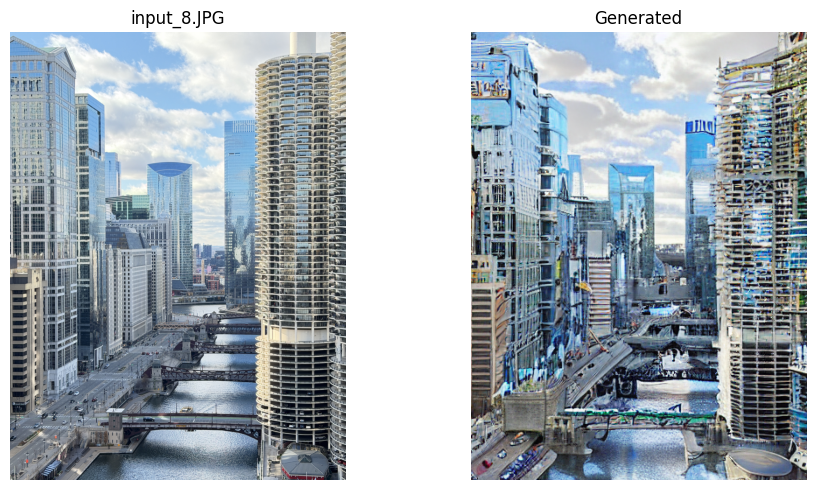

In [36]:
# Visualize generated outputs
for image_path in input_image_paths:
    image_name = image_path.name

    if image_name in generation_results and generation_results[image_name]["status"] == "success":
        input_img = load_image(str(image_path))
        output_img = load_image(generation_results[image_name]["output_image_path"])
        display_side_by_side(input_img, output_img, title1=image_name, title2="Generated")

# 3.4 Critique and Evaluation Agent
- Task: Evaluate the generated image relative to the input image and prompt. 
- Requirements: Assess: 
    - visual relevance 
    - prompt faithfulness 
    - quality of the transformation 
<br>

Include: 
- one automatic signal where feasible (e.g., CLIP similarity) 
- a simple human evaluation rubric across 3–5 examples

The agent should produce a short critique indicating whether the output should be accepted or revised. 

In [37]:
import open_clip

# output schema
@dataclass
class CritiqueOutput:
    visual_relevance_score: int
    prompt_faithfulness_score: int
    transformation_quality_score: int
    clip_similarity: float
    critique: str
    decision: str
    

# Critique and Evaluation Agent implementation
class CritiqueEvaluationAgent:
    """
    This agent evaluates the generated image relative to the prompt and the
    expected transformation. It also computes one automatic signal using CLIP.
    """

    def __init__(self):
        self.clip_model, _, self.preprocess = open_clip.create_model_and_transforms(
            "ViT-B-32",
            pretrained="openai"
        )
        self.tokenizer = open_clip.get_tokenizer("ViT-B-32")
        self.clip_model = self.clip_model.to(DEVICE)
        self.clip_model.eval()

    @torch.no_grad()
    def compute_clip_image_text_similarity(self, image: Image.Image, text: str) -> float:
        """Compute cosine similarity between image and prompt text."""
        image_tensor = self.preprocess(image).unsqueeze(0).to(DEVICE)
        text_tokens = self.tokenizer([text]).to(DEVICE)

        image_features = self.clip_model.encode_image(image_tensor)
        text_features = self.clip_model.encode_text(text_tokens)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        similarity = (image_features @ text_features.T).item()
        return float(similarity)

    def score_from_similarity(self, similarity: float) -> int:
        """Convert similarity into a simple 1 to 5 score."""
        if similarity > 0.32:
            return 5
        elif similarity > 0.28:
            return 4
        elif similarity > 0.24:
            return 3
        elif similarity > 0.20:
            return 2
        else:
            return 1

    def run(self, generated_image_path: str, prompt_output: PromptOutput) -> CritiqueOutput:
        """Evaluate one generated image."""
        generated_img = load_image(generated_image_path)
        clip_similarity = self.compute_clip_image_text_similarity(
            generated_img,
            prompt_output.refined_prompt
        )

        prompt_faithfulness_score = self.score_from_similarity(clip_similarity)
        visual_relevance_score = prompt_faithfulness_score
        transformation_quality_score = prompt_faithfulness_score

        if prompt_faithfulness_score >= 4:
            critique = (
                "The output is visually relevant to the refined prompt and preserves the key image content. "
                "The transformation quality is acceptable."
            )
            decision = "accept"
        elif prompt_faithfulness_score == 3:
            critique = (
                "The output partially matches the refined prompt but may require another generation pass "
                "for stronger transformation quality."
            )
            decision = "revise"
        else:
            critique = (
                "The output has limited alignment with the refined prompt and should be revised."
            )
            decision = "revise"

        return CritiqueOutput(
            visual_relevance_score=visual_relevance_score,
            prompt_faithfulness_score=prompt_faithfulness_score,
            transformation_quality_score=transformation_quality_score,
            clip_similarity=round(clip_similarity, 4),
            critique=critique,
            decision=decision
        )
        
        
# Run Agent
critique_agent = CritiqueEvaluationAgent()
critique_results = {}

for image_path in input_image_paths:
    image_name = image_path.name

    if image_name not in generation_results:
        critique_results[image_name] = {
            "visual_relevance_score": None,
            "prompt_faithfulness_score": None,
            "transformation_quality_score": None,
            "clip_similarity": None,
            "critique": "Generation output is missing, so evaluation could not be completed.",
            "decision": "revise"
        }
        continue

    g_result = generation_results[image_name]

    if g_result["status"] == "success":
        prompt_output = PromptOutput(**prompt_results[image_name])
        critique_output = critique_agent.run(
            generated_image_path=g_result["output_image_path"],
            prompt_output=prompt_output
        )
        critique_results[image_name] = asdict(critique_output)
    else:
        critique_results[image_name] = {
            "visual_relevance_score": None,
            "prompt_faithfulness_score": None,
            "transformation_quality_score": None,
            "clip_similarity": None,
            "critique": "Generation failed, so evaluation could not be completed.",
            "decision": "revise"
        }

print("Task 3.4 completed.")


# Inspect outputs
critique_rows = []

for image_name, result in critique_results.items():
    critique_rows.append({
        "image_name": image_name,
        "visual_relevance_score": result.get("visual_relevance_score"),
        "prompt_faithfulness_score": result.get("prompt_faithfulness_score"),
        "transformation_quality_score": result.get("transformation_quality_score"),
        "clip_similarity": result.get("clip_similarity"),
        "decision": result.get("decision"),
        "critique": result.get("critique")
    })

critique_df = pd.DataFrame(critique_rows)

# sort by image name for cleaner display
critique_df = critique_df.sort_values("image_name").reset_index(drop=True)

print("Task 3.4 critique table:")
display(critique_df)

Task 3.4 completed.
Task 3.4 critique table:


,image_name,visual_relevance_score,prompt_faithfulness_score,transformation_quality_score,clip_similarity,decision,critique
0,input_1.JPG,4,4,4,0.2839,accept,The output is visually relevant to the refined...
1,input_2.JPG,2,2,2,0.2217,revise,The output has limited alignment with the refi...
2,input_3.JPG,3,3,3,0.2791,revise,The output partially matches the refined promp...
3,input_4.JPG,2,2,2,0.2265,revise,The output has limited alignment with the refi...
4,input_5.JPEG,3,3,3,0.2575,revise,The output partially matches the refined promp...
5,input_6.JPG,2,2,2,0.2295,revise,The output has limited alignment with the refi...
6,input_7.JPG,3,3,3,0.2433,revise,The output partially matches the refined promp...
7,input_8.JPG,2,2,2,0.2267,revise,The output has limited alignment with the refi...


# 3.5 Integration and Execution
1. <b>Modular Design</b>: Each agent must be implemented as an independent module. 
2. <b>Workflow</b>: Implement orchestration showing agent communication and intermediate outputs. 
3. <b>Multi-Agent Collaboration</b>: The workflow should demonstrate how agents interact in sequence: <br>
    `Vision Understanding → Prompt Engineering → Image Generation → Critique/Evaluation. `
4. Testing: Validate the system on at least three use cases, such as: <br>
    a. image captioning and visual questions <br>
    b. style-guided image transformation <br>
    c. prompt-based image enhancement 
5. Failure Handling: Handle ambiguous prompts, poor-quality images, or generation errors gracefully. 

In [38]:
# Task 3.5 - Integration and Execution
final_results = []

for image_path in input_image_paths:
    image_name = image_path.name

    case_result = {
        "image_name": image_name,
        "input_image_path": str(image_path),
        "vision_output": vision_results.get(image_name),
        "prompt_output": prompt_results.get(image_name),
        "generation_output": generation_results.get(image_name),
        "critique_output": critique_results.get(image_name)
    }

    final_results.append(case_result)

    log_path = LOG_DIR / f"{image_path.stem}_log.json"
    save_json(case_result, str(log_path))

print("Task 3.5 completed.")
print("Logs saved to:", LOG_DIR)

Task 3.5 completed.
Logs saved to: agent_logs


In [39]:
# Task 3.5 - Summary results table
summary_rows = []

for image_path in input_image_paths:
    image_name = image_path.name
    g = generation_results.get(image_name, {})
    c = critique_results.get(image_name, {})

    summary_rows.append({
        "image_name": image_name,
        "generation_status": g.get("status"),
        "model_name": g.get("model_name"),
        "inference_steps": g.get("num_inference_steps"),
        "clip_similarity": c.get("clip_similarity"),
        "visual_relevance_score": c.get("visual_relevance_score"),
        "prompt_faithfulness_score": c.get("prompt_faithfulness_score"),
        "transformation_quality_score": c.get("transformation_quality_score"),
        "decision": c.get("decision")
    })

summary_df = pd.DataFrame(summary_rows)
summary_csv_path = OUTPUT_DIR / "summary_results.csv"
summary_df.to_csv(summary_csv_path, index=False)

print("Summary results saved to:", summary_csv_path)
summary_df

Summary results saved to: generated_outputs/summary_results.csv


,image_name,generation_status,model_name,inference_steps,clip_similarity,visual_relevance_score,prompt_faithfulness_score,transformation_quality_score,decision
0,input_1.JPG,success,runwayml/stable-diffusion-v1-5,20,0.2839,4,4,4,accept
1,input_2.JPG,success,runwayml/stable-diffusion-v1-5,20,0.2217,2,2,2,revise
2,input_3.JPG,success,runwayml/stable-diffusion-v1-5,20,0.2791,3,3,3,revise
3,input_4.JPG,success,runwayml/stable-diffusion-v1-5,20,0.2265,2,2,2,revise
4,input_5.JPEG,success,runwayml/stable-diffusion-v1-5,20,0.2575,3,3,3,revise
5,input_6.JPG,success,runwayml/stable-diffusion-v1-5,20,0.2295,2,2,2,revise
6,input_7.JPG,success,runwayml/stable-diffusion-v1-5,20,0.2433,3,3,3,revise
7,input_8.JPG,success,runwayml/stable-diffusion-v1-5,20,0.2267,2,2,2,revise


In [40]:
# Failure handling demonstration
failure_test_cases = [
    {
        "image_path": str(INPUT_DIR / "missing_input.jpg"),
        "user_request": "edit it"
    },
    {
        "image_path": str(INPUT_DIR / "input_1.JPG"),
        "user_request": "fix"
    }
]

for case in failure_test_cases:
    print("\n" + "=" * 80)
    print("Testing case:", case)

    if not Path(case["image_path"]).exists():
        print("Handled missing file error successfully.")
        continue

    safe_request = ensure_prompt_is_clear(case["user_request"])
    print("Original request:", case["user_request"])
    print("Fallback request used:", safe_request)


Testing case: {'image_path': 'input_images/missing_input.jpg', 'user_request': 'edit it'}
Handled missing file error successfully.

Testing case: {'image_path': 'input_images/input_1.JPG', 'user_request': 'fix'}
Original request: fix
Fallback request used: Enhance the image while preserving the main subject and improving visual clarity.
